In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

2026-05-23 18:34:00.967209: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
RESULTS_DIR = "/home/jovyan/results"
MODELS_DIR = "/home/jovyan/models"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5
EPOCHS = 15
LEARNING_RATE = 5e-6

In [3]:
train_df = pd.read_csv(os.path.join(RESULTS_DIR, "train_split_5class.csv"))
val_df = pd.read_csv(os.path.join(RESULTS_DIR, "val_split_5class.csv"))
test_df = pd.read_csv(os.path.join(RESULTS_DIR, "test_split_5class.csv"))

In [4]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["dx"].value_counts())

print("\nValidation distribution:")
print(val_df["dx"].value_counts())

print("\nTest distribution:")
print(test_df["dx"].value_counts())

print("\nLabels:")
print(train_df["label"].value_counts().sort_index())

Train: 7025
Validation: 781
Test: 1952

Train distribution:
dx
nv       4827
mel       801
bkl       791
bcc       370
akiec     236
Name: count, dtype: int64

Validation distribution:
dx
nv       537
mel       89
bkl       88
bcc       41
akiec     26
Name: count, dtype: int64

Test distribution:
dx
nv       1341
mel       223
bkl       220
bcc       103
akiec      65
Name: count, dtype: int64

Labels:
label
0     236
1     370
2     791
3     801
4    4827
Name: count, dtype: int64


In [5]:
remove_classes = ["df", "vasc"]

train_df = train_df[~train_df["dx"].isin(remove_classes)]
val_df = val_df[~val_df["dx"].isin(remove_classes)]
test_df = test_df[~test_df["dx"].isin(remove_classes)]

print(len(train_df), len(val_df), len(test_df))

7025 781 1952


In [6]:
label_map = {
    "akiec": 0,
    "bcc": 1,
    "bkl": 2,
    "mel": 3,
    "nv": 4
}

train_df["label"] = train_df["dx"].map(label_map)
val_df["label"] = val_df["dx"].map(label_map)
test_df["label"] = test_df["dx"].map(label_map)

In [8]:
classes = np.sort(train_df["label"].unique())

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    int(c): min(float(w), 3.0)
    for c, w in zip(classes, class_weights_array)}

print(class_weights)

{0: 3.0, 1: 3.0, 2: 1.7762326169405815, 3: 1.7540574282147317, 4: 0.29107105862854776}


In [9]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)

    image = preprocess_input(image)

    return image, label

In [10]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values, train_df["label"].values))

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].values, val_df["label"].values))

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values, test_df["label"].values))

train_ds = (
    train_ds
    .map(load_image)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

val_ds = (
    val_ds
    .map(load_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

test_ds = (
    test_ds
    .map(load_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

I0000 00:00:1779561286.802334    9693 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1234 MB memory:  -> device: 0, name: NVIDIA A16, pci bus id: 0000:2a:00.0, compute capability: 8.6


In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [12]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

In [13]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs, outputs)

In [14]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,412,072 (16.83 MB)

 Trainable params: 1,858,149 (7.09 MB)

 Non-trainable params: 2,553,923 (9.74 MB)

In [15]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15


E0000 00:00:1779561320.429624    9693 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-05-23 18:35:31.031934: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


220/220 ━━━━━━━━━━━━━━━━━━━━ 61s 185ms/step - accuracy: 0.1294 - loss: 1.9110 - val_accuracy: 0.1946 - val_loss: 1.7613
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 43s 189ms/step - accuracy: 0.1841 - loss: 1.6940 - val_accuracy: 0.2830 - val_loss: 1.7444
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 198ms/step - accuracy: 0.2352 - loss: 1.5821 - val_accuracy: 0.3547 - val_loss: 1.6100
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 44s 190ms/step - accuracy: 0.2975 - loss: 1.4726 - val_accuracy: 0.4328 - val_loss: 1.4562
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 198ms/step - accuracy: 0.3458 - loss: 1.3942 - val_accuracy: 0.4789 - val_loss: 1.3525
Epoch 6/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 196ms/step - accuracy: 0.3905 - loss: 1.3204 - val_accuracy: 0.5134 - val_loss: 1.2721
Epoch 7/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 44s 196ms/step - accuracy: 0.4326 - loss: 1.2510 - val_accuracy: 0.5544 - val_loss: 1.1784
Epoch 8/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 43s 188ms/step - accuracy: 0.4542 - loss: 1.2250 - val

In [17]:
model.save(os.path.join(MODELS_DIR, "efficientnet_5class1_3.0.keras"))

In [18]:
y_true = np.concatenate([
    y for x, y in test_ds
])

y_probs = model.predict(test_ds)

y_pred = np.argmax(y_probs, axis=1)

2026-05-23 18:46:50.918756: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step


In [19]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

print("\nClassification Report:\n")

target_names = list(label_map.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=target_names
))

balanced_acc = balanced_accuracy_score(y_true, y_pred)

print("\nBalanced Accuracy:", balanced_acc)

[[ 18   7  20  20   0]
 [  8  45  22  20   8]
 [ 11   7 126  55  21]
 [  5   1  52 133  32]
 [  9  36 101 250 945]]

Classification Report:

              precision    recall  f1-score   support

       akiec       0.35      0.28      0.31        65
         bcc       0.47      0.44      0.45       103
         bkl       0.39      0.57      0.47       220
         mel       0.28      0.60      0.38       223
          nv       0.94      0.70      0.81      1341

    accuracy                           0.65      1952
   macro avg       0.49      0.52      0.48      1952
weighted avg       0.76      0.65      0.68      1952


Balanced Accuracy: 0.5175308192329675


In [21]:
import numpy as np

cm = np.array([
    [18,  7,  20,  20,   0],
    [ 8, 45,  22,  20,   8],
    [11,  7, 126,  55,  21],
    [ 5,  1,  52, 133,  32],
    [ 9, 36, 101, 250, 945]
])

class_index = 3  # melanoma

tp = cm[class_index, class_index]
fn = np.sum(cm[class_index, :]) - tp
fp = np.sum(cm[:, class_index]) - tp
tn = np.sum(cm) - (tp + fn + fp)

specificity = tn / (tn + fp)

print("Melanoma Specificity:", specificity)

Melanoma Specificity: 0.8004626951995373


In [23]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

7025
781
1952
label
4    4827
3     801
2     791
1     370
0     236
Name: count, dtype: int64
label
4    1341
3     223
2     220
1     103
0      65
Name: count, dtype: int64


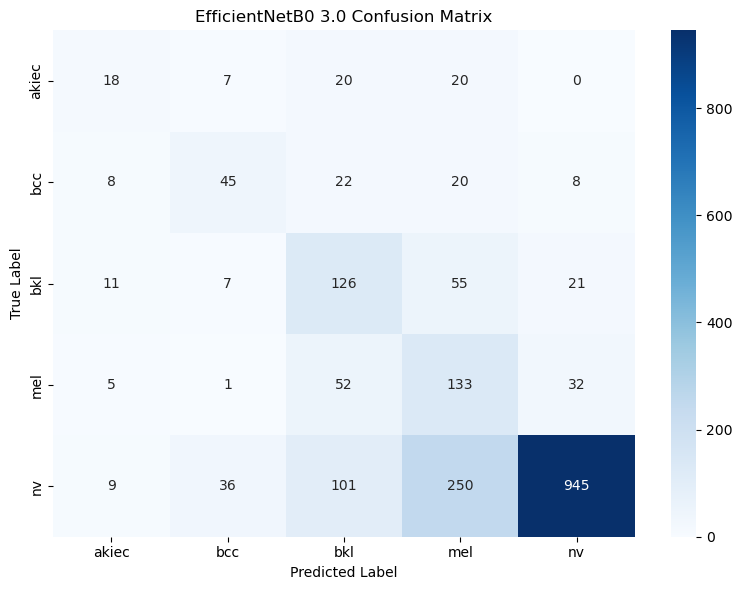

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ["akiec", "bcc", "bkl", "mel", "nv"]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 3.0 Confusion Matrix")
plt.tight_layout()
plt.show()

In [28]:
import os
import pandas as pd

# 1. Create folder name
output_dir = "efficientnetb0_3_0_results"

# 2. Create the folder if it does not exist
os.makedirs(output_dir, exist_ok=True)

# 3. Create training history table
history_df = pd.DataFrame(history.history)

history_df["generalization_gap"] = (
    history_df["accuracy"] - history_df["val_accuracy"]
)

history_df["val_accuracy_change"] = history_df["val_accuracy"].diff().abs()
history_df["val_loss_change"] = history_df["val_loss"].diff().abs()

# 4. Save inside the folder
save_path = os.path.join(output_dir, "training_history.csv")
history_df.to_csv(save_path, index=False)

print("Saved training history to:", save_path)

# 5. Show files inside folder
print("Files in folder:", os.listdir(output_dir))

history_df

Saved training history to: efficientnetb0_3_0_results/training_history.csv
Files in folder: ['training_history.csv']


,accuracy,loss,val_accuracy,val_loss,generalization_gap,val_accuracy_change,val_loss_change
0,0.129395,1.911001,0.194622,1.761326,-0.065227,NaN,NaN
1,0.184057,1.694036,0.282971,1.744367,-0.098914,0.088348,0.016958
2,0.235160,1.582112,0.354674,1.609979,-0.119513,0.071703,0.134388
3,0.297509,1.472588,0.432778,1.456190,-0.135270,0.078105,0.153789
4,0.345765,1.394206,0.478873,1.352534,-0.133108,0.046095,0.103656
5,0.390463,1.320385,0.513444,1.272149,-0.122982,0.034571,0.080385
6,0.432598,1.251008,0.554417,1.178398,-0.121820,0.040973,0.093751
7,0.454235,1.225046,0.559539,1.129162,-0.105304,0.005122,0.049236
8,0.487829,1.185323,0.587708,1.061884,-0.099879,0.028169,0.067279
9,0.514591,1.143370,0.588988,1.038958,-0.074398,0.001280,0.022926


In [29]:
summary_metrics = {
    "Final Training Accuracy": history_df["accuracy"].iloc[-1],
    "Final Validation Accuracy": history_df["val_accuracy"].iloc[-1],
    "Final Training Loss": history_df["loss"].iloc[-1],
    "Final Validation Loss": history_df["val_loss"].iloc[-1],
    "Best Validation Accuracy": history_df["val_accuracy"].max(),
    "Best Validation Accuracy Epoch": history_df["val_accuracy"].idxmax() + 1,
    "Best Validation Loss": history_df["val_loss"].min(),
    "Best Validation Loss Epoch": history_df["val_loss"].idxmin() + 1,
    "Final Generalization Gap": history_df["generalization_gap"].iloc[-1],
    "Average Generalization Gap": history_df["generalization_gap"].mean(),
    "Validation Accuracy Instability": history_df["val_accuracy_change"].mean(),
    "Validation Loss Instability": history_df["val_loss_change"].mean(),
    "Validation Accuracy Std": history_df["val_accuracy"].std(),
    "Validation Loss Std": history_df["val_loss"].std()
}

summary_metrics_df = pd.DataFrame(
    summary_metrics.items(),
    columns=["Metric", "Value"]
)

summary_metrics_df.to_csv(f"{output_dir}/training_summary_metrics.csv", index=False)

summary_metrics_df

,Metric,Value
0,Final Training Accuracy,0.593452
1,Final Validation Accuracy,0.633803
2,Final Training Loss,0.999630
3,Final Validation Loss,0.914929
4,Best Validation Accuracy,0.633803
5,Best Validation Accuracy Epoch,15.000000
6,Best Validation Loss,0.914929
7,Best Validation Loss Epoch,15.000000
8,Final Generalization Gap,-0.040351
9,Average Generalization Gap,-0.091553


In [30]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

cm_df.to_csv(f"{output_dir}/confusion_matrix.csv")

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(f"{output_dir}/classification_report.csv")

report_df

,precision,recall,f1-score,support
akiec,0.352941,0.276923,0.310345,65.000000
bcc,0.468750,0.436893,0.452261,103.000000
bkl,0.392523,0.572727,0.465804,220.000000
mel,0.278243,0.596413,0.379458,223.000000
nv,0.939364,0.704698,0.805283,1341.000000
accuracy,0.649078,0.649078,0.649078,0.649078
macro avg,0.486364,0.517531,0.482630,1952.000000
weighted avg,0.757845,0.649078,0.683267,1952.000000


In [32]:
import os
import numpy as np
import pandas as pd

# Create output folder
output_dir = "efficientnetb0_5class_3_0_results"
os.makedirs(output_dir, exist_ok=True)

# Confusion matrix
cm = np.array([
    [18,  7,  20,  20,   0],
    [ 8, 45,  22,  20,   8],
    [11,  7, 126,  55,  21],
    [ 5,  1,  52, 133,  32],
    [ 9, 36, 101, 250, 945]
])

class_names = ["akiec", "bcc", "bkl", "mel", "nv"]
mel_index = 3

# Basic totals
total = np.sum(cm)
correct = np.trace(cm)

test_accuracy = correct / total

# Class-wise recall
class_recall = np.diag(cm) / np.sum(cm, axis=1)

# Class-wise precision
class_precision = np.diag(cm) / np.sum(cm, axis=0)

# Class-wise F1
class_f1 = 2 * (class_precision * class_recall) / (class_precision + class_recall)

# Support
support = np.sum(cm, axis=1)

# Macro metrics
balanced_accuracy = np.mean(class_recall)
macro_precision = np.mean(class_precision)
macro_recall = np.mean(class_recall)
macro_f1 = np.mean(class_f1)

# Weighted metrics
weighted_precision = np.average(class_precision, weights=support)
weighted_recall = np.average(class_recall, weights=support)
weighted_f1 = np.average(class_f1, weights=support)

# Melanoma metrics
tp = cm[mel_index, mel_index]
fn = np.sum(cm[mel_index, :]) - tp
fp = np.sum(cm[:, mel_index]) - tp
tn = np.sum(cm) - (tp + fn + fp)

melanoma_recall = tp / (tp + fn)
melanoma_specificity = tn / (tn + fp)

# Final metrics table
final_metrics = {
    "Test Accuracy": test_accuracy,
    "Balanced Accuracy": balanced_accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted Precision": weighted_precision,
    "Weighted Recall": weighted_recall,
    "Weighted F1": weighted_f1,
    "Melanoma Recall": melanoma_recall,
    "Melanoma Specificity": melanoma_specificity
}

final_metrics_df = pd.DataFrame(
    final_metrics.items(),
    columns=["Metric", "Value"]
)

# Save file
save_path = os.path.join(output_dir, "final_test_metrics.csv")
final_metrics_df.to_csv(save_path, index=False)

print("Saved final metrics to:", save_path)
print("Files in folder:", os.listdir(output_dir))

final_metrics_df

Saved final metrics to: efficientnetb0_5class_3_0_results/final_test_metrics.csv
Files in folder: ['training_history.csv', 'final_test_metrics.csv']


,Metric,Value
0,Test Accuracy,0.649078
1,Balanced Accuracy,0.517531
2,Macro Precision,0.486364
3,Macro Recall,0.517531
4,Macro F1,0.482630
5,Weighted Precision,0.757845
6,Weighted Recall,0.649078
7,Weighted F1,0.683267
8,Melanoma Recall,0.596413
9,Melanoma Specificity,0.800463


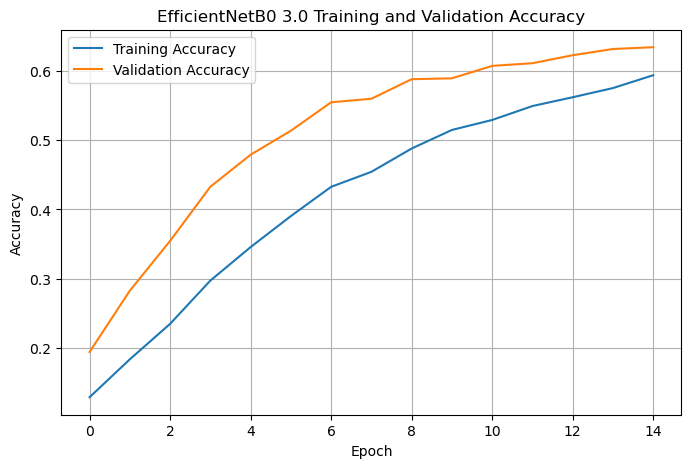

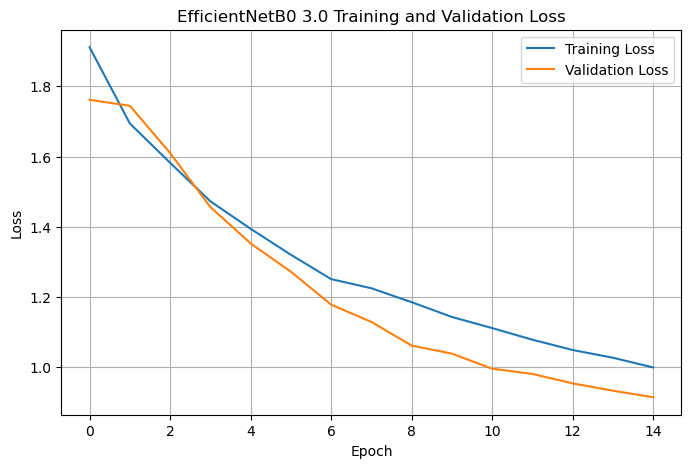

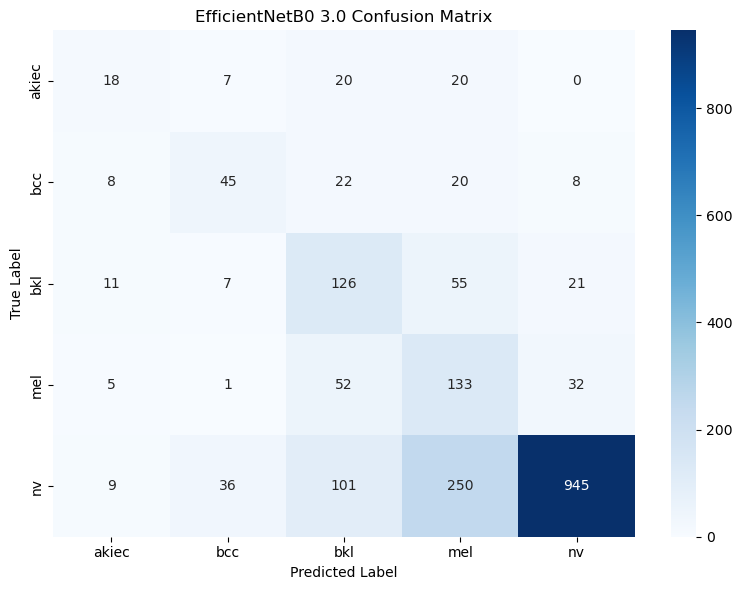

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 3.0 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(f"{output_dir}/training_validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 3.0 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{output_dir}/training_validation_loss.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 3.0 Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{output_dir}/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()